In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.neighbors import KNeighborsRegressor

import xgboost as xgb

import matplotlib.pyplot as plt

### 1. Load the dataset and split into train/test

In [15]:
# Load the CSV (10 feature columns + 1 target column)
df = pd.read_csv("quasars.csv", header=None)  

X = df.iloc[:, 0:10].values
y = df.iloc[:, 10].values

# Split into train & test (80% train, 20% test)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

### 2. Fit an XGBoost with prescribed hyperparameters + 10% hold‐out from training


#### 2.1) Create a small hold‐out from the training set

In [3]:
# Split X_train_full into X_train (90%) and X_val (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=1
)

print("Sizes for XGBoost fitting + validation:")
print("  X_train:", X_train.shape, "y_train:", y_train.shape)
print("  X_val:  ", X_val.shape, "y_val:  ", y_val.shape)

Sizes for XGBoost fitting + validation:
  X_train: (14400, 10) y_train: (14400,)
  X_val:   (1600, 10) y_val:   (1600,)


#### 2.2) Build and train the XGBoost Regressor

In [5]:
xgb_base = xgb.XGBRegressor(
    objective="reg:squarederror",
    colsample_bytree=0.5,
    learning_rate=0.1,
    max_depth=4,
    reg_lambda=1,
    n_estimators=500,
    random_state=42,
    eval_metric="rmse"
)

xgb_base.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)
evals_result = xgb_base.evals_result()

#### 2.3) Plot Training & Validation RMSE vs. Iteration

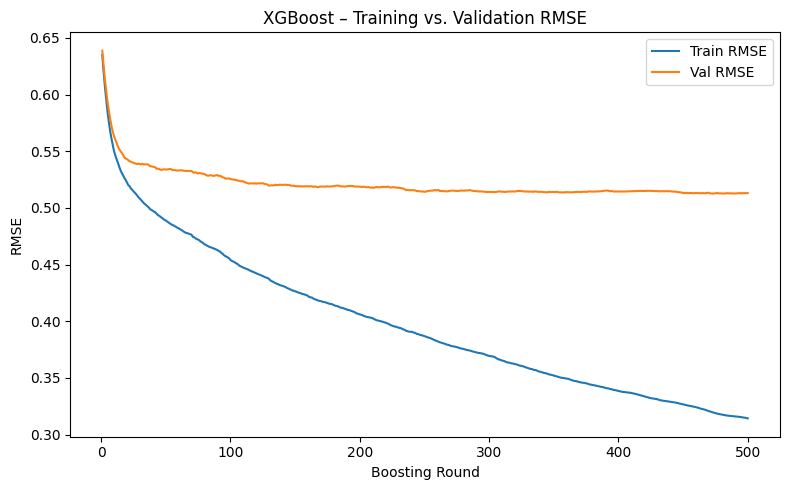

In [18]:
train_rmse = evals_result["validation_0"]["rmse"]
val_rmse   = evals_result["validation_1"]["rmse"]
iterations = np.arange(1, len(train_rmse) + 1)

plt.figure(figsize=(8, 5))
plt.plot(iterations, train_rmse, label="Train RMSE")
plt.plot(iterations, val_rmse,   label="Val RMSE")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost – Training vs. Validation RMSE")
plt.legend()
plt.tight_layout()
plt.savefig("xgboost_base_rmse.png")
plt.show()

#### 2.4) Evaluate on the Test Set

In [8]:
y_pred_test = xgb_base.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2   = r2_score(y_test, y_pred_test)

print(f"Base XGBRegressor (given hyperparams) on test set:")
print(f"RMSE = {test_rmse:.4f}")
print(f"R^2 = {test_r2:.4f}")

Base XGBRegressor (given hyperparams) on test set:
RMSE = 0.4989
R^2 = 0.3214


### 3. Grid‐Search for Better XGBoost Hyperparameters (3‐fold CV)

#### 3.1) Choose a Grid of Hyperparameters

In [20]:
param_grid = {
    # vary colsample_bytree around 0.5
    "colsample_bytree": [0.3, 0.4, 0.5, 0.6, 0.7],
    # vary learning_rate around 0.1
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    # vary max_depth around 4
    "max_depth": [2, 3, 4, 5, 6],
    # vary reg_lambda (lambda) around 1
    "reg_lambda": [0.1, 0.5, 1.0, 2.0, 5.0],
    # also consider fewer / more boosting rounds
    "n_estimators": [200, 300, 500, 700, 900]
}

#### 3.2) Set up GridSearchCV with 3‐fold CV, optimizing for RMSE

In [21]:
xgb_for_gs = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_for_gs,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_full, y_train_full)

best_params = grid_search.best_params_
best_score_negRmse = grid_search.best_score_

print("Best hyperparameters (3‐fold CV on the training pool):")
print(best_params)
print(f"Average CV‐RMSE = {-best_score_negRmse:.5f}")

Fitting 3 folds for each of 3125 candidates, totalling 9375 fits
Best hyperparameters (3‐fold CV on the training pool):
{'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 500, 'reg_lambda': 2.0}
Average CV‐RMSE = 0.50502


#### 3.3) Re‐train XGBoost on all training data with best_params

In [22]:
xgb_best = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    colsample_bytree=best_params["colsample_bytree"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"],
    n_estimators=best_params["n_estimators"],
    reg_lambda=best_params["reg_lambda"]
)

xgb_best.fit(X_train_full, y_train_full)

y_pred_best = xgb_best.predict(X_test)

test_rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
test_r2_best   = r2_score(y_test, y_pred_best)

print("Tuned XGBoost on test set:")
print(f"RMSE = {test_rmse_best:.4f}")
print(f"R^2 = {test_r2_best:.4f}")

Tuned XGBoost on test set:
RMSE = 0.4682
R^2 = 0.4023


### 4. Compare to a 5‐NN Regression Baseline

In [23]:
knn5 = KNeighborsRegressor(n_neighbors=5)

knn5.fit(X_train_full, y_train_full)

y_pred_knn5 = knn5.predict(X_test)

knn_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn5))
knn_test_r2   = r2_score(y_test, y_pred_knn5)

print("5‐NN Regressor on test set:")
print(f"RMSE = {knn_test_rmse:.4f}")
print(f"R^2 = {knn_test_r2:.4f}")

5‐NN Regressor on test set:
RMSE = 0.4798
R^2 = 0.3722
